In [3]:
import re
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize
import numpy as np

torch.manual_seed(42)

[nltk_data] Downloading package punkt to /Users/art/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/art/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
with open('article.txt','r', encoding="utf-8") as f:
    text = f.read()

In [6]:
paragraphs = [p.strip() for p in text.split('\n') if len(p.strip()) > 80]
len(paragraphs)

66

In [7]:
def tokenize(p):
    tokens = word_tokenize(p.lower())
    return [t for t in tokens if t.isalpha()]

In [8]:
tokenized_paragraphs = [tokenize(p) for p in paragraphs]

In [11]:
all_tokens = [t for toks in tokenized_paragraphs for t in toks]

In [12]:
vocab_counter = Counter(all_tokens)

In [20]:
vocab = ["<PAD>", "<UNK>"] + [w for w,c in vocab_counter.most_common()]
word2idx = {w:i for i,w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
VOCAB_SIZE

1368

In [22]:
length = np.array([len(toks) for toks in tokenized_paragraphs])

length.min()

15

In [24]:
length.max()

166

In [25]:
length.mean()

77.83333333333333

In [26]:
np.percentile(length,90)

122.0

In [27]:
np.percentile(length,95)

139.5

In [28]:
np.percentile(length,99)

159.49999999999994

In [29]:
import matplotlib.pyplot as plt

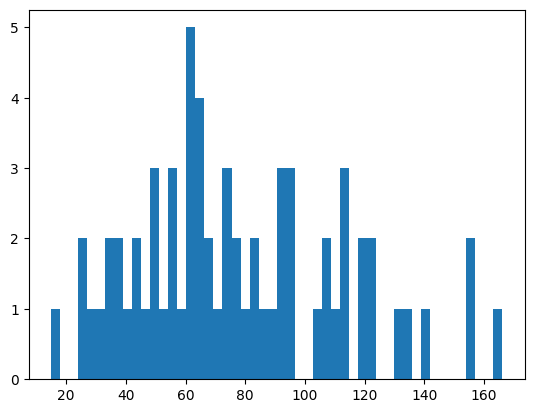

In [31]:
plt.hist(length, bins=50);

In [78]:
MAX_LEN = 140

def encode(tokens, max_len=MAX_LEN):
    idx = [word2idx.get(t,1) for t in tokens]
    if len(idx) >= max_len:
        return idx[:max_len]
    return idx + [0] *(max_len- len(idx))

In [79]:
def has_quote(p):
    return 'quote' if ('\u201c' in p or '\u201d' in p) else 'no_quote'


In [80]:
raw_labels = [has_quote(p) for p in paragraphs]
y = np.array(list(map(lambda x : 0 if x=='no_quote' else 1, raw_labels)))

In [81]:
X_sequences = [encode(toks) for toks in tokenized_paragraphs]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X_sequences, y, test_size=0.3, random_state=42)

In [84]:
class ParagraphDataset(Dataset):
    def __init__(self, sequenses, labels):
        self.X = torch.tensor(sequenses, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [85]:
train_ds = ParagraphDataset(X_train, y_train)
test_ds = ParagraphDataset(X_test,y_test)

In [89]:
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

In [90]:
EMBED_DIM = 50

In [91]:
NUM_CLASSES = 2

In [93]:
class DenseClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size,embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, 32)
        self.fc2 = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        embedded = self.embedding(x)
        pooled = embedded.mean(dim=1)
        h = self.relu(self.fc1(pooled))
        return self.fc2(self.dropout(h))

In [99]:
class CNNClasifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, num_filter=32, kernel_sizes=(2,3,4) ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([ nn.Conv1d(embed_dim, num_filter, kernel_size=k) for k in kernel_sizes])
        self.fc = nn.Linear(num_filter* len(kernel_sizes), num_classes)
        self.dropout = nn.Dropout(0.3) 
    
    def forward(self, x):
        embedded = self.embedding(x).permute(0,2,1)
        conv_outs = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))
            pooled = torch.max(c, dim=2)[0]
            conv_outs.append(pooled)
        combined = torch.cat(conv_outs, dim=1)
        return self.fc(self.dropout(combined))

In [101]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, hidden_dim=32 ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self,x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        final_hidden = torch.cat((hidden[0], hidden[1]), dim=1)
        return self.fc(self.dropout(final_hidden))